# TFT + SARIMAX

In [1]:
import pandas as pd
import numpy as np

import lightning.pytorch as pl
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.metrics import MultiLoss, QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping
from pytorch_forecasting.data.encoders import MultiNormalizer, GroupNormalizer

import torch

from pmdarima import auto_arima

import pickle
import os

import matplotlib.pyplot as plt
import seaborn as sns

import holidays
from datetime import timedelta

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

/home/dulara/project/mlgpu/lib/python3.12/site-packages/pytorch_forecasting/models/base/_base_model.py:28: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [2]:
df = pd.read_csv("Baththaramulla_data_training.csv")

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38566 entries, 0 to 38565
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Period Start Time                   38566 non-null  object 
 1   AT                                  38566 non-null  float64
 2   RH                                  38566 non-null  float64
 3   BP                                  38566 non-null  float64
 4   Solar Rad                           38566 non-null  float64
 5   Rain Gauge                          38566 non-null  float64
 6   WD Raw                              38566 non-null  float64
 7   O3 Conc                             38566 non-null  float64
 8   NO Conc                             38566 non-null  float64
 9   NO2 Conc                            38566 non-null  float64
 10  NOx Conc                            38566 non-null  float64
 11  SO2 Conc                            38566

In [4]:
df.rename(columns={'PM2.5 Conc': 'PM2 5 Conc', 'PM2.5 Conc_lag24': 'PM2 5 Conc_lag24', 'PM2.5 Conc_rolling24_mean': 'PM2 5 Conc_rolling24_mean', 'PM2.5 Conc_rolling24_std': 'PM2 5 Conc_rolling24_std'}, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38566 entries, 0 to 38565
Data columns (total 38 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Period Start Time                   38566 non-null  object 
 1   AT                                  38566 non-null  float64
 2   RH                                  38566 non-null  float64
 3   BP                                  38566 non-null  float64
 4   Solar Rad                           38566 non-null  float64
 5   Rain Gauge                          38566 non-null  float64
 6   WD Raw                              38566 non-null  float64
 7   O3 Conc                             38566 non-null  float64
 8   NO Conc                             38566 non-null  float64
 9   NO2 Conc                            38566 non-null  float64
 10  NOx Conc                            38566 non-null  float64
 11  SO2 Conc                            38566

In [6]:
# rim whitespace and remove CR/LF
s = df['Period Start Time'].astype(str).str.strip().str.replace(r'[\r\n]', '', regex=True)

# remove trailing ".000" or other fractional seconds if present
s = s.str.replace(r'\.(\d{1,6})$', r'.\1', regex=True)

# remove all fractional seconds:
s_no_ms = s.str.replace(r'\.\d+$', '', regex=True)

# parsing with milliseconds format first (handles "YYYY-MM-DD HH:MM:SS.fff")
parsed = pd.to_datetime(s, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

# if that produced NaT for some rows, try no-ms variant
mask_failed = parsed.isna()
if mask_failed.any():
    parsed.loc[mask_failed] = pd.to_datetime(s_no_ms[mask_failed],
                                             format='%Y-%m-%d %H:%M:%S',
                                             errors='coerce')

# Put result back
df['Period Start Time'] = parsed
print("Remaining unparsable:", df['Period Start Time'].isna().sum())

Remaining unparsable: 0


## Train TFT for All

In [7]:
# 1. Define Targets (Multi-Pollutant)
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'SO2 Conc', 'NO2 Conc', 'O3 Conc']

In [8]:
# 2. Define Feature Groups
# Features known in the future (Calendar/Monsoon/Policy)
known_reals = ['sin_hour', 'cos_hour', 'sin_day_of_year', 'cos_day_of_year']
known_cats = ['is_weekend', 'is_holiday', 'traffic_hour', 'is_covid_lockdown', 
              'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
              'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon']

# Features unknown in the future (Weather/Pollutants/Rolling)
unknown_reals = [
    'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge', 'WD Raw',
    'NO Conc', 'NOx Conc',
    'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean', 'PM2 5 Conc_rolling24_std',
    'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean', 'PM10 Conc_rolling24_std',
    'NO2 Conc_lag24', 'NO2 Conc_rolling24_mean', 'NO2 Conc_rolling24_std',
    'AT_rolling72_mean', 'RH_rolling72_mean', 'Solar Rad_rolling72_mean'
]

In [9]:
# 3. Create Dataset
max_prediction_length = 24
max_encoder_length = 14 * 24

In [10]:
# 1. Ensure your data is sorted by time
if 'Period Start Time' in df.columns:
    df = df.sort_values('Period Start Time')
else:
    df = df.sort_index()

# 2. Add the Group ID 
df['group_id'] = 'location_1'

# 3. Create the 'time_idx' Column
df['time_idx'] = df.groupby('group_id').cumcount()

# --- Check if it worked ---
print(df[['time_idx', 'group_id']].head())

   time_idx    group_id
0         0  location_1
1         1  location_1
2         2  location_1
3         3  location_1
4         4  location_1


In [11]:
training_cutoff = df["time_idx"].max() - max_prediction_length

In [12]:
# --- FIX: Convert Categorical Columns to Strings ---

# 1. Convert 'is_weekend' and 'is_holiday' (booleans/ints) to strings
df['is_weekend'] = df['is_weekend'].astype(str).astype('category')
df['is_holiday'] = df['is_holiday'].astype(str).astype('category')

# 2. Convert 'traffic_hour' (integers 0-23) to strings
# The model treats "Hour 5" as a category, not a number
df['traffic_hour'] = df['traffic_hour'].astype(str).astype('category')

# 3. Convert 'is_covid_lockdown' (integers 0/1) to strings
df['is_covid_lockdown'] = df['is_covid_lockdown'].astype(str).astype('category')

# 4. Convert Monsoon Columns (if they are 0/1 integers)
# Get all monsoon phase columns
monsoon_cols = [col for col in df.columns if 'monsoon_phase_' in col]
for col in monsoon_cols:
    df[col] = df[col].astype(str).astype('category')

print("Categorical columns successfully converted to strings!")

Categorical columns successfully converted to strings!


In [13]:
# --- 1. Define the MultiNormalizer ---
# We create a list of normalizers, one for each target in your TARGETS list.
# We use GroupNormalizer which is standard for TFT.
# transformation="softplus" is good for pollutants because they cannot be negative.
target_normalizer = MultiNormalizer(
    [GroupNormalizer(groups=["group_id"], transformation="softplus") for _ in TARGETS]
)

# --- 2. Create the Dataset with the Fix ---
training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=TARGETS,
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=known_cats,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=target_normalizer, 
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

print("Training dataset created successfully!")

# Create validation set from training set
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

Training dataset created successfully!


In [ ]:
# --- 1. Data Loaders---
train_dataloader = training.to_dataloader(
    train=True, 
    batch_size=64, 
    num_workers=11 
)
val_dataloader = validation.to_dataloader(
    train=False, 
    batch_size=64, 
    num_workers=11
)

# --- 2. Configure a TFT Model ---
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=128,              
    attention_head_size=4,       
    dropout=0.15,
    hidden_continuous_size=64,   
    loss=MultiLoss(metrics=[QuantileLoss()] * len(TARGETS)),
    reduce_on_plateau_patience=4,
)

# --- 3. Configure the Trainer ---
early_stop_callback = EarlyStopping(
    monitor="val_loss", 
    min_delta=1e-4, 
    patience=10, 
    verbose=False, 
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=30,            
    accelerator='gpu',       
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
    enable_model_summary=True,
)

# --- 4. Train! ---
print("Starting Training...")
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting Training...



   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | MultiLoss                       | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 16     | train
3  | prescalers                         | ModuleDict                      | 4.6 K  | train
4  | static_variable_selection          | VariableSelectionNetwork        | 291 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 707 K  | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 138 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 66.3 K | train
8  | static_context_initial_hidden_lstm | GatedResidualNetwork            | 66.3 K 

Epoch 6:  67%|██████▋   | 399/596 [06:18<03:06,  1.05it/s, v_num=18, train_loss_step=8.090, val_loss=42.00, train_loss_epoch=9.610]  


Detected KeyboardInterrupt, attempting graceful shutdown ...


### Save Model Just in Case

In [23]:
# # --- Option 1: Manual Save (Simplest) ---
# trainer.save_checkpoint("tft_model_final.ckpt")
# print("TFT Model saved successfully!")

# # --- Option 2: Automatic Best Model Saving (Recommended) ---
# best_model_path = trainer.checkpoint_callback.best_model_path
# print(f"Best model was saved automatically at: {best_model_path}")

In [24]:
# # Load the model
# loaded_tft = TemporalFusionTransformer.load_from_checkpoint(
#     "tft_model_final.ckpt",
#     map_location="cpu" 
# )

# print("TFT Model loaded!")

### Generating residuals

In [ ]:
# 1. Define how much history we want for the Residual Training
history_days = 30
history_steps = history_days * 24

# 2. Select the last 30 days of data
cutoff_start = df['time_idx'].max() - history_steps - (7*24) 
history_data = df[lambda x: x.time_idx >= cutoff_start]

# 3. Create a "Rolling" Dataset (predict=False allows rolling windows)
residual_dataset = TimeSeriesDataSet.from_dataset(
    training, 
    history_data, 
    predict=False, 
    stop_randomization=True
)

# 4. Create DataLoader
residual_dataloader = residual_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

print(f"Generating residuals for the last {history_days} days...")

Generating residuals for the last 30 days...


In [31]:
# 1. Predict using the MODEL (tft)
raw_predictions, x, index, *ignored = tft.predict(
    residual_dataloader, 
    mode="raw", 
    return_x=True, 
    return_index=True
)

# 2. Extract Median (Quantile 3)
tft_preds_batch = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1)

# 3. Get Actuals directly from 'x'
actuals_batch = x['decoder_target']

# --- THE FIX IS HERE ---
# If actuals_batch is a list (Multi-Target), stack it into a Tensor
if isinstance(actuals_batch, list):
    actuals_batch = torch.stack(actuals_batch, dim=-1)

# 4. Flattening (Taking the first hour of every window)
tft_series = tft_preds_batch[:, 0, :].detach().cpu().numpy()
actual_series = actuals_batch[:, 0, :].detach().cpu().numpy()

# 5. Calculate Residuals
long_residuals = actual_series - tft_series

print(f"New Residuals Shape: {long_residuals.shape}")

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


New Residuals Shape: (698, 5)


## Train Sarima for Residuals

In [32]:
sarima_models = {}

for i, target_name in enumerate(TARGETS):
    print(f"\n--- Training SARIMA for {target_name} Residuals ---")
    
    # Get the error series for this pollutant
    error_series = long_residuals[:, i]
    error_series = error_series[~np.isnan(error_series)]
    
    # Train Auto-ARIMA
    model = auto_arima(
        error_series,
        start_p=0, start_q=0,
        max_p=2, max_q=2,
        m=24,              
        seasonal=True,
        d=None,          
        trace=True,
        error_action='ignore',
        suppress_warnings=True
    )
    
    sarima_models[target_name] = model
    print(f"Best SARIMA order for {target_name}: {model.order}")


--- Training SARIMA for PM2 5 Conc Residuals ---
Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[24] intercept   : AIC=5595.765, Time=0.98 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=5591.773, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=5188.932, Time=1.08 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=5304.710, Time=1.35 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=5604.225, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=5188.927, Time=0.07 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=5189.107, Time=1.25 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=5189.666, Time=2.12 sec
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=5190.927, Time=0.13 sec
 ARIMA(1,0,1)(0,0,0)[24] intercept   : AIC=5190.927, Time=0.08 sec
 ARIMA(0,0,1)(0,0,0)[24] intercept   : AIC=5303.818, Time=0.08 sec
 ARIMA(2,0,1)(0,0,0)[24] intercept   : AIC=5192.522, Time=0.20 sec
 ARIMA(1,0,0)(0,0,0)[24]             : AIC=5189.512, Time=0.02 sec

Best model:  ARIMA(1,0,0)(0,0,0)[24

### Save model just in Case

In [ ]:
import os

# Save the dictionary of SARIMA models
with open("sarima_residuals.pkl", "wb") as f:
    pickle.dump(sarima_models, f)

print("SARIMA models saved successfully!")

In [ ]:
with open("sarima_residuals.pkl", "rb") as f:
    loaded_sarima_models = pickle.load(f)

print("SARIMA models loaded!")

SARIMA models loaded!


## Visualization

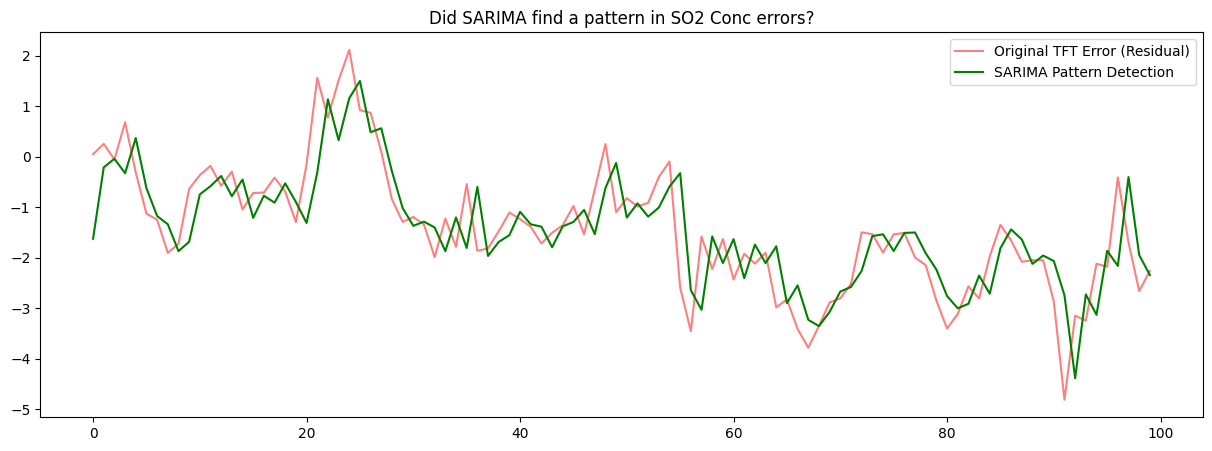

In [43]:
# PM 2.5
target_idx = 2
target_name = TARGETS[target_idx]

# 1. Get original TFT error
original_error = long_residuals[:, target_idx]

# 2. See what SARIMA predicts for this error
sarima_correction = sarima_models[target_name].predict_in_sample()

# 3. Plot
plt.figure(figsize=(15, 5))
plt.plot(original_error[:100], label='Original TFT Error (Residual)', color='red', alpha=0.5)
plt.plot(sarima_correction[:100], label='SARIMA Pattern Detection', color='green')
plt.title(f"Did SARIMA find a pattern in {target_name} errors?")
plt.legend()
plt.show()

### Load Models if Needed

In [ ]:
# --- A. Load TFT Model ---
# This contains the neural network AND the dataset configuration
loaded_tft = TemporalFusionTransformer.load_from_checkpoint(
    "tft_model_final.ckpt",
    map_location="cpu" 
)
print("TFT Model loaded!")

# --- B. Load SARIMA Models ---
# You need these for the hybrid correction
with open("saved_models/sarima_residuals.pkl", "rb") as f:
    loaded_sarima_models = pickle.load(f)
print("SARIMA Models loaded!")

/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/utilities/parsing.py:210: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.


TFT Model loaded!
SARIMA Models loaded!


## Evaluate the models

In [46]:
# --- 1. CONFIGURATION ---
HORIZON = 24  # Forecast window (e.g., last 24 hours)
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'SO2 Conc', 'NO2 Conc', 'O3 Conc']

# --- 2. PREPARE TEST DATA ---
# We define the "Test Set" as the last 24 hours of your dataframe.
last_time_idx = df['time_idx'].max()
test_start_idx = last_time_idx - HORIZON + 1

# Get the Actual Values (Ground Truth) for this period
actuals_df = df[df['time_idx'] >= test_start_idx].copy()
actuals = actuals_df[TARGETS].values  # Shape: [24, 5]

print(f"Evaluating Forecast for time_idx: {test_start_idx} to {last_time_idx}")

# --- 3. GENERATE TFT BASELINE FORECAST (CORRECTED) ---
# We need to create a prediction dataset that includes the history leading up to the test set
max_encoder_length = training.max_encoder_length # Get directly from training dataset
cutoff = test_start_idx - 1 

# Filter the dataframe MANUALLY to include:
# 1. The necessary history for the encoder
# 2. The 24-hour test window (ground truth)
evaluation_df = df[
    (df['time_idx'] > cutoff - max_encoder_length) & 
    (df['time_idx'] <= last_time_idx)
].copy()

# Create the dataset for inference
evaluation_dataset = TimeSeriesDataSet.from_dataset(
    training,       
    evaluation_df,   
    predict=True,   
    stop_randomization=True
)
evaluation_dataloader = evaluation_dataset.to_dataloader(train=False, batch_size=1)

# Predict
print("Running TFT Prediction...")
# Note: Use tft.predict, NOT trainer.predict
raw_predictions, x, index, *ignored = tft.predict(
    evaluation_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

# Extract Median Forecast (P50)
tft_preds = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1).squeeze(0).detach().cpu().numpy()

# --- 4. GENERATE SARIMA CORRECTION ---
print("Running SARIMA Prediction...")
sarima_corrections = []

for i, target in enumerate(TARGETS):
    # Ensure we use the correct model for each target
    if target in sarima_models:
        # Predict the next 24 hours of residuals
        correction = sarima_models[target].predict(n_periods=HORIZON)
        sarima_corrections.append(correction)
    else:
        # Fallback if no model exists (e.g., if you skipped some)
        sarima_corrections.append(np.zeros(HORIZON))

# Stack to match shape [HORIZON, Targets]
sarima_corrections = np.column_stack(sarima_corrections)

# --- 5. CALCULATE HYBRID FORECAST ---
hybrid_preds = tft_preds + sarima_corrections

# --- 6. COMPUTE METRICS ---
metrics_list = []

for i, target in enumerate(TARGETS):
    # Get columns for this target
    act = actuals[:, i]
    base = tft_preds[:, i]
    hyb = hybrid_preds[:, i]
    
    # Calculate Base Metrics
    rmse_base = np.sqrt(mean_squared_error(act, base))
    mae_base = mean_absolute_error(act, base)
    r2_base = r2_score(act, base)
    
    # Calculate Hybrid Metrics
    rmse_hyb = np.sqrt(mean_squared_error(act, hyb))
    mae_hyb = mean_absolute_error(act, hyb)
    r2_hyb = r2_score(act, hyb)
    
    # Improvement (Positive = Hybrid is better)
    imp_rmse = rmse_base - rmse_hyb
    
    metrics_list.append({
        "Pollutant": target,
        "Base RMSE": round(rmse_base, 2),
        "Hybrid RMSE": round(rmse_hyb, 2),
        "RMSE Improv.": f"{imp_rmse:.2f}",
        "Base R2": round(r2_base, 3),
        "Hybrid R2": round(r2_hyb, 3)
    })

# --- 7. DISPLAY RESULTS ---
results_df = pd.DataFrame(metrics_list)
print("\n========== FINAL EVALUATION: BASELINE VS HYBRID ==========")
print(results_df.to_string(index=False))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True


Evaluating Forecast for time_idx: 38542 to 38565
Running TFT Prediction...


TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Running SARIMA Prediction...

========== FINAL EVALUATION: BASELINE VS HYBRID ==========
 Pollutant  Base RMSE  Hybrid RMSE RMSE Improv.  Base R2  Hybrid R2
PM2 5 Conc      19.02        17.95         1.07   -1.114     -0.882
 PM10 Conc      24.81        21.38         3.43   -1.299     -0.708
  SO2 Conc       2.48         1.37         1.11   -6.430     -1.254
  NO2 Conc       4.58         4.00         0.58    0.086      0.303
   O3 Conc      11.43        11.28         0.15    0.164      0.186


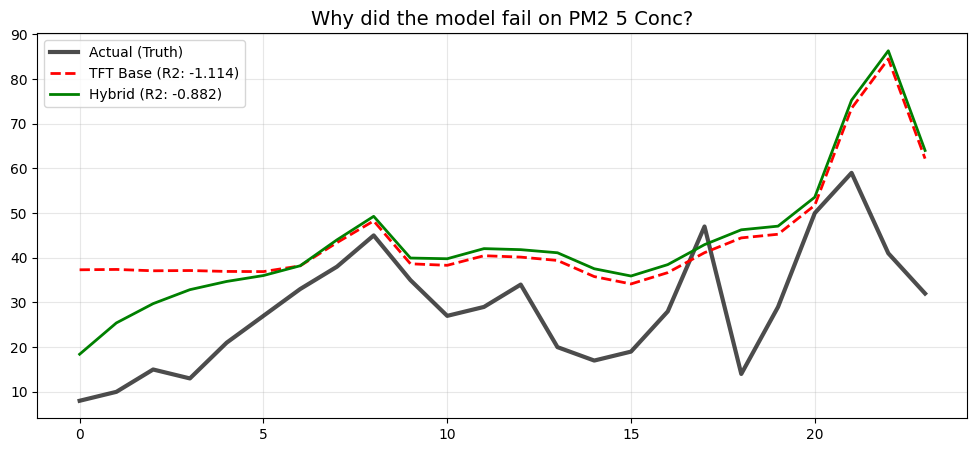

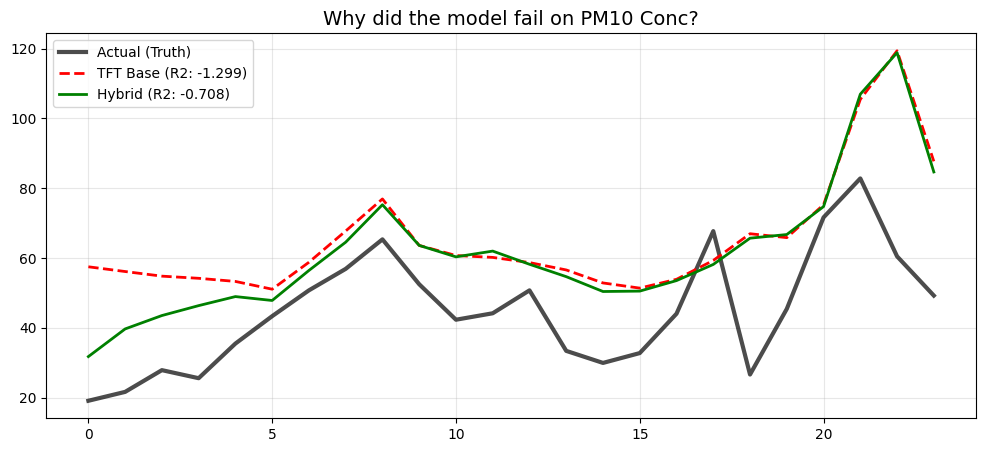

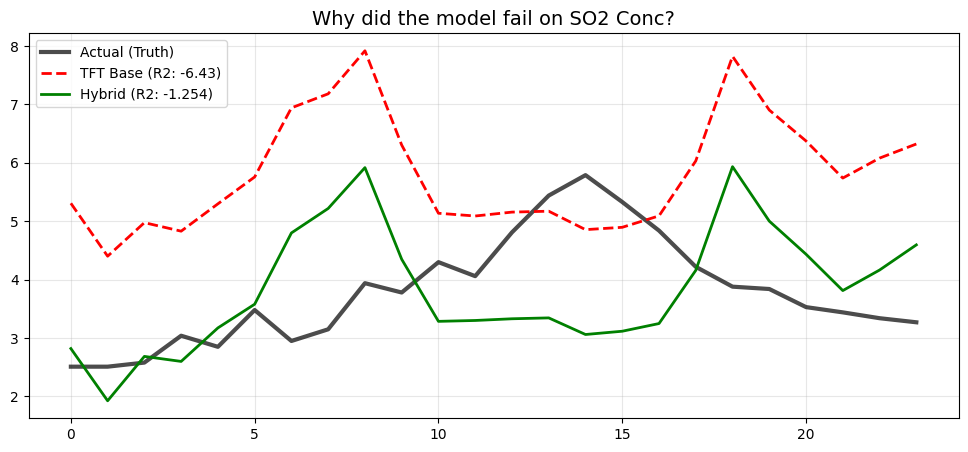

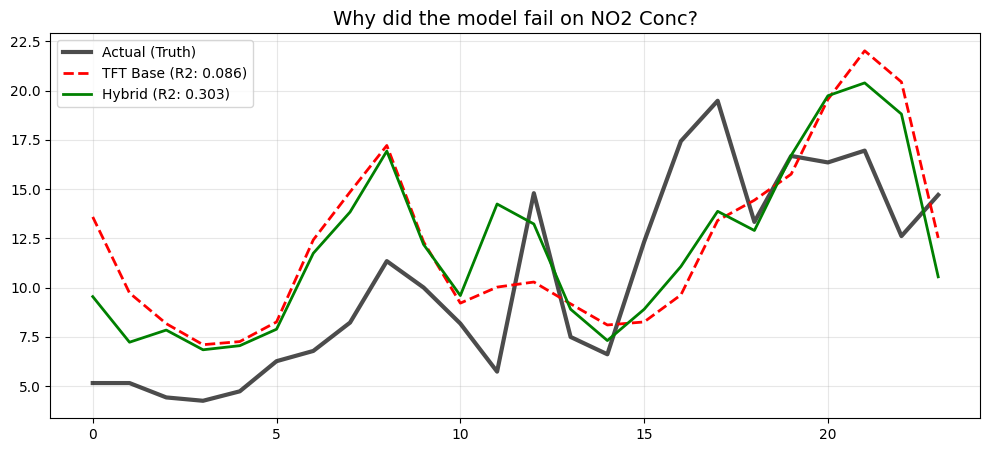

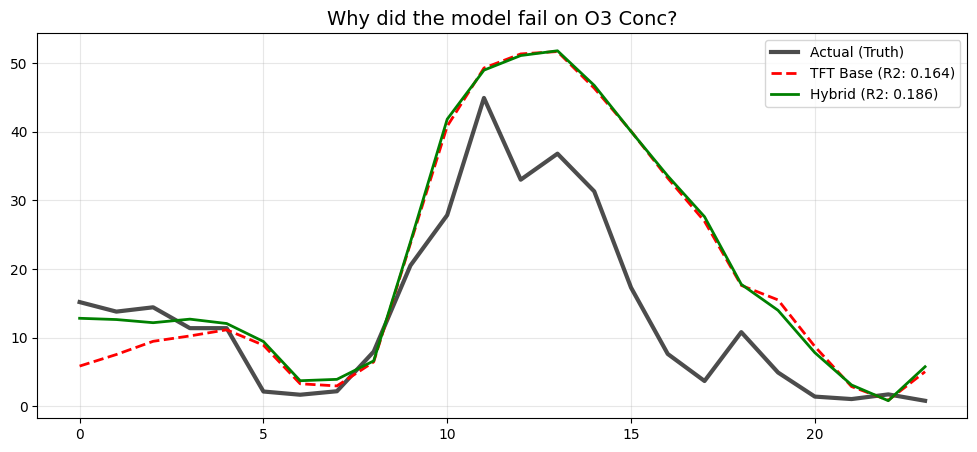

In [47]:
# Create a plot for each pollutant
for i, target in enumerate(TARGETS):
    plt.figure(figsize=(12, 5))
    
    # 1. Plot Ground Truth (Black)
    plt.plot(actuals[:, i], label='Actual (Truth)', color='black', linewidth=3, alpha=0.7)
    
    # 2. Plot TFT Base (Red - The Failure)
    plt.plot(tft_preds[:, i], label=f'TFT Base (R2: {results_df.iloc[i]["Base R2"]})', 
             color='red', linestyle='--', linewidth=2)
    
    # 3. Plot Hybrid (Green - The Fix)
    plt.plot(hybrid_preds[:, i], label=f'Hybrid (R2: {results_df.iloc[i]["Hybrid R2"]})', 
             color='green', linewidth=2)
    
    plt.title(f"Why did the model fail on {target}?", fontsize=14)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [79]:
# --- CONFIGURATION ---
DAYS_TO_EVAL = 7  
HORIZON = 24      
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'SO2 Conc', 'NO2 Conc', 'O3 Conc']

print(f"Starting Robust {DAYS_TO_EVAL}-Day Evaluation...")

# Storage for all metrics
all_metrics = {t: {'rmse_base': [], 'rmse_hyb': [], 'r2_base': [], 'r2_hyb': []} for t in TARGETS}

# Get the last available time index
total_max_idx = df['time_idx'].max()

# --- LOOP THROUGH LAST 7 DAYS ---
for day in range(DAYS_TO_EVAL):
    # Calculate the specific 24-hour window for this "day"
    # day=0 is the last day, day=1 is yesterday, etc.
    test_end_idx = total_max_idx - (day * 24)
    test_start_idx = test_end_idx - 23
    
    # 1. Get Actuals for this window
    actuals_df = df[(df['time_idx'] >= test_start_idx) & (df['time_idx'] <= test_end_idx)]
    if len(actuals_df) < 24: continue # Skip if data is missing
    actuals = actuals_df[TARGETS].values

    # 2. Prepare TFT Prediction for this window
    # We need history before the test_start_idx
    cutoff = test_start_idx - 1
    
    # Slice data for the model
    eval_df = df[
        (df['time_idx'] > cutoff - max_encoder_length) & 
        (df['time_idx'] <= test_end_idx)
    ].copy()
    
    # Create dataset
    eval_ds = TimeSeriesDataSet.from_dataset(
        training, eval_df, predict=True, stop_randomization=True
    )
    eval_dl = eval_ds.to_dataloader(train=False, batch_size=1)
    
    # Predict TFT
    raw_preds, x, idx, *ignored = tft.predict(eval_dl, mode="raw", return_x=True, return_index=True)
    tft_preds = torch.stack([p[..., 3] for p in raw_preds['prediction']], dim=-1).squeeze(0).detach().cpu().numpy()

    # 3. Predict SARIMA (Residual Correction)
    sarima_corrections = []
    for t_name in TARGETS:
        if t_name in sarima_models:
            # We predict N periods ahead. 
            sarima_corrections.append(sarima_models[t_name].predict(n_periods=HORIZON))
        else:
            sarima_corrections.append(np.zeros(HORIZON))
    sarima_corrections = np.column_stack(sarima_corrections)

    # 4. Calculate Hybrid
    hybrid_preds = tft_preds + sarima_corrections

    # 5. Calculate Metrics for this specific day
    for i, target in enumerate(TARGETS):
        # Base (TFT)
        rmse_b = np.sqrt(mean_squared_error(actuals[:, i], tft_preds[:, i]))
        r2_b = r2_score(actuals[:, i], tft_preds[:, i])
        
        # Hybrid
        rmse_h = np.sqrt(mean_squared_error(actuals[:, i], hybrid_preds[:, i]))
        r2_h = r2_score(actuals[:, i], hybrid_preds[:, i])
        
        # Store
        all_metrics[target]['rmse_base'].append(rmse_b)
        all_metrics[target]['rmse_hyb'].append(rmse_h)
        all_metrics[target]['r2_base'].append(r2_b)
        all_metrics[target]['r2_hyb'].append(r2_h)

# --- FINAL AGGREGATION ---
print("\n========== 7-DAY ROBUST PERFORMANCE REPORT ==========")
summary_list = []

for target in TARGETS:
    m = all_metrics[target]
    
    # Average the scores over 7 days
    avg_rmse_base = np.mean(m['rmse_base'])
    avg_rmse_hyb = np.mean(m['rmse_hyb'])
    avg_r2_base = np.mean(m['r2_base'])
    avg_r2_hyb = np.mean(m['r2_hyb'])
    
    # Improvement
    imp = avg_rmse_base - avg_rmse_hyb
    
    summary_list.append({
        "Pollutant": target,
        "Avg Base RMSE": round(avg_rmse_base, 2),
        "Avg Hybrid RMSE": round(avg_rmse_hyb, 2),
        "RMSE Improv.": f"{imp:.2f}",
        "Avg Base R2": round(avg_r2_base, 3),
        "Avg Hybrid R2": round(avg_r2_hyb, 3)
    })

results_df = pd.DataFrame(summary_list)
print(results_df.to_string(index=False))

💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Starting Robust 7-Day Evaluation...


/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
💡 Tip: For seamless cloud uploads


========== 7-DAY ROBUST PERFORMANCE REPORT ==========
 Pollutant  Avg Base RMSE  Avg Hybrid RMSE RMSE Improv.  Avg Base R2  Avg Hybrid R2
PM2 5 Conc          13.89            14.69        -0.79        0.145          0.150
 PM10 Conc          17.69            18.15        -0.45        0.061          0.168
  SO2 Conc           2.48             2.34         0.14       -4.078         -1.472
  NO2 Conc           3.24             3.56        -0.32        0.431          0.303
   O3 Conc           7.22             7.33        -0.11        0.731          0.727


## Creating the Data Set for Future Predictions

In [ ]:
# --- Configuration ---
HORIZON = 24
TARGETS = ['PM2.5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

# --- Helper: Get Last Date from your current data ---
last_time_idx = df['time_idx'].max()
last_date = df['Period Start Time'].max()

# --- Generate Future Timestamps ---
future_dates = [last_date + timedelta(hours=i+1) for i in range(HORIZON)]
future_df = pd.DataFrame({'Period Start Time': future_dates})
future_df['time_idx'] = range(last_time_idx + 1, last_time_idx + 1 + HORIZON)
future_df['group_id'] = 'location_1'

# --- Generate Features ---
future_df['hour'] = future_df['Period Start Time'].dt.hour
future_df['day_of_year'] = future_df['Period Start Time'].dt.dayofyear

future_df['sin_hour'] = np.sin(2 * np.pi * future_df['hour'] / 24)
future_df['cos_hour'] = np.cos(2 * np.pi * future_df['hour'] / 24)
future_df['sin_day_of_year'] = np.sin(2 * np.pi * future_df['day_of_year'] / 365.25)
future_df['cos_day_of_year'] = np.cos(2 * np.pi * future_df['day_of_year'] / 365.25)

# --- FORCE FORMATTING: "0" and "1" Strings ---
print("Formatting future data...")

sl_holidays = holidays.SriLanka()

# Calculate raw values
future_df['is_weekend'] = (future_df['Period Start Time'].dt.dayofweek >= 5)
future_df['is_holiday'] = future_df['Period Start Time'].dt.date.isin(sl_holidays)
future_df['is_covid_lockdown'] = 0
future_df['traffic_hour'] = future_df['hour']

# Monsoon Logic (Simplified)
monsoon_cols = [
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]
for col in monsoon_cols: future_df[col] = 0

current_month = future_df['Period Start Time'].dt.month.iloc[0]
if 5 <= current_month <= 9: future_df['monsoon_phase_Southwest Monsoon'] = 1
elif 12 <= current_month or current_month <= 2: future_df['monsoon_phase_Northeast Monsoon'] = 1

# THE FIX: Force everything to Int -> String ("0"/"1")
cat_cols = ['is_weekend', 'is_holiday', 'is_covid_lockdown', 'traffic_hour'] + monsoon_cols

for col in cat_cols:
    # Coerce to number, fill NaNs, convert to int, then string
    future_df[col] = pd.to_numeric(future_df[col], errors='coerce').fillna(0).astype(int).astype(str)

print("Future Data formatted successfully!")

Formatting future data...
Future Data formatted successfully!


In [ ]:
# --- 1. CONFIGURATION ---
HORIZON = 24
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

# --- 2. GENERATE FUTURE DATA ---
last_time_idx = df['time_idx'].max()
last_date = df['Period Start Time'].max()

future_dates = [last_date + timedelta(hours=i+1) for i in range(HORIZON)]
future_df = pd.DataFrame({'Period Start Time': future_dates})
future_df['time_idx'] = range(last_time_idx + 1, last_time_idx + 1 + HORIZON)
future_df['group_id'] = 'location_1'

# Time Features
future_df['hour'] = future_df['Period Start Time'].dt.hour
future_df['day_of_year'] = future_df['Period Start Time'].dt.dayofyear
future_df['sin_hour'] = np.sin(2 * np.pi * future_df['hour'] / 24)
future_df['cos_hour'] = np.cos(2 * np.pi * future_df['hour'] / 24)
future_df['sin_day_of_year'] = np.sin(2 * np.pi * future_df['day_of_year'] / 365.25)
future_df['cos_day_of_year'] = np.cos(2 * np.pi * future_df['day_of_year'] / 365.25)

# --- 3. CATEGORICAL ALIGNMENT (The Fix for 'KeyError') ---
sl_holidays = holidays.SriLanka()

# Generate raw values first
future_df['is_weekend'] = (future_df['Period Start Time'].dt.dayofweek >= 5)
future_df['is_holiday'] = future_df['Period Start Time'].dt.date.isin(sl_holidays)
future_df['is_covid_lockdown'] = 0 
future_df['traffic_hour'] = future_df['hour']

# Monsoon Logic
monsoon_cols = [
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]
for col in monsoon_cols: future_df[col] = 0

current_month = future_df['Period Start Time'].dt.month.iloc[0]
if 5 <= current_month <= 9: future_df['monsoon_phase_Southwest Monsoon'] = 1
elif 12 <= current_month or current_month <= 2: future_df['monsoon_phase_Northeast Monsoon'] = 1

# Check Model Requirements and Force Format
print("Aligning categories to model...")
model_encoders = loaded_tft.dataset_parameters['categorical_encoders']

for col_name, encoder in model_encoders.items():
    if col_name in future_df.columns:
        allowed = set(encoder.classes_.keys())
        
        # Force format based on what model knows
        if '0' in allowed: # Model wants Strings "0"/"1"
            future_df[col_name] = future_df[col_name].fillna(0).astype(int).astype(str)
        elif 'False' in allowed: # Model wants Strings "False"/"True"
            future_df[col_name] = future_df[col_name].fillna(0).astype(bool).astype(str)
        elif '0.0' in allowed: # Model wants Strings "0.0"/"1.0"
            future_df[col_name] = future_df[col_name].fillna(0).astype(float).astype(str)
            
        # Special Traffic Hour Fix (Force to '0' if '2' causes crash)
        if col_name == 'traffic_hour':
            # Check if we have values that don't exist in allowed
            current_vals = set(future_df[col_name].unique())
            if not current_vals.issubset(allowed):
                print(f"   -> Forcing traffic_hour to '0' to prevent crash")
                future_df[col_name] = list(allowed)[0] # Pick safe default

# --- 4. DATASET CREATION ---
needed_cols = loaded_tft.dataset_parameters['time_varying_unknown_reals'] + TARGETS
for col in needed_cols:
    if col not in future_df.columns:
        future_df[col] = 0.0

history_cutoff = last_time_idx - (7*24)
history_needed = df[lambda x: x.time_idx > history_cutoff]
prediction_df = pd.concat([history_needed, future_df], ignore_index=True)

inference_dataset = TimeSeriesDataSet.from_parameters(
    loaded_tft.dataset_parameters, 
    prediction_df, 
    predict=True, 
    stop_randomization=True
)
inference_dataloader = inference_dataset.to_dataloader(train=False, batch_size=1)

# --- 5. HYBRID PREDICTION ---
print("Running Hybrid Prediction...")

# A. TFT Forecast
# mode="quantiles" returns the list of tensors directly
raw_predictions, x, *index = loaded_tft.predict(inference_dataloader, mode="quantiles", return_x=True)

# --- THE FIX IS HERE: Removed ['prediction'] ---
tft_preds = torch.stack([p[..., 3] for p in raw_predictions], dim=-1).squeeze(0).detach().cpu().numpy()

# B. SARIMA Forecast
sarima_corrections = []
for i, target_name in enumerate(TARGETS):
    if target_name in loaded_sarima_models:
        sarima_corrections.append(loaded_sarima_models[target_name].predict(n_periods=HORIZON))
    else:
        sarima_corrections.append(np.zeros(HORIZON))

# C. Combine
final_forecast = tft_preds + np.column_stack(sarima_corrections)

# D. Display
result_df = pd.DataFrame(final_forecast, columns=TARGETS)
result_df.insert(0, 'Time', future_dates)

print("\n--- Final Hybrid Forecast Generated ---")
print(result_df.head())

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Aligning categories to model...
   -> Forcing traffic_hour to '0' to prevent crash
Running Hybrid Prediction...


/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.



--- Final Hybrid Forecast Generated ---
                 Time  PM2 5 Conc  PM10 Conc  NO2 Conc    O3 Conc  SO2 Conc
0 2025-01-01 00:00:00   11.394242  23.861031  2.612160  16.166930  6.996351
1 2025-01-01 01:00:00   13.821369  26.468710  2.830399  16.328572  5.902467
2 2025-01-01 02:00:00   14.647468  28.004209  4.628977  13.908935  5.161897
3 2025-01-01 03:00:00   17.404685  30.067627  4.450794  12.987867  4.747413
4 2025-01-01 04:00:00   20.334801  33.862301  4.642000  11.144656  4.190691


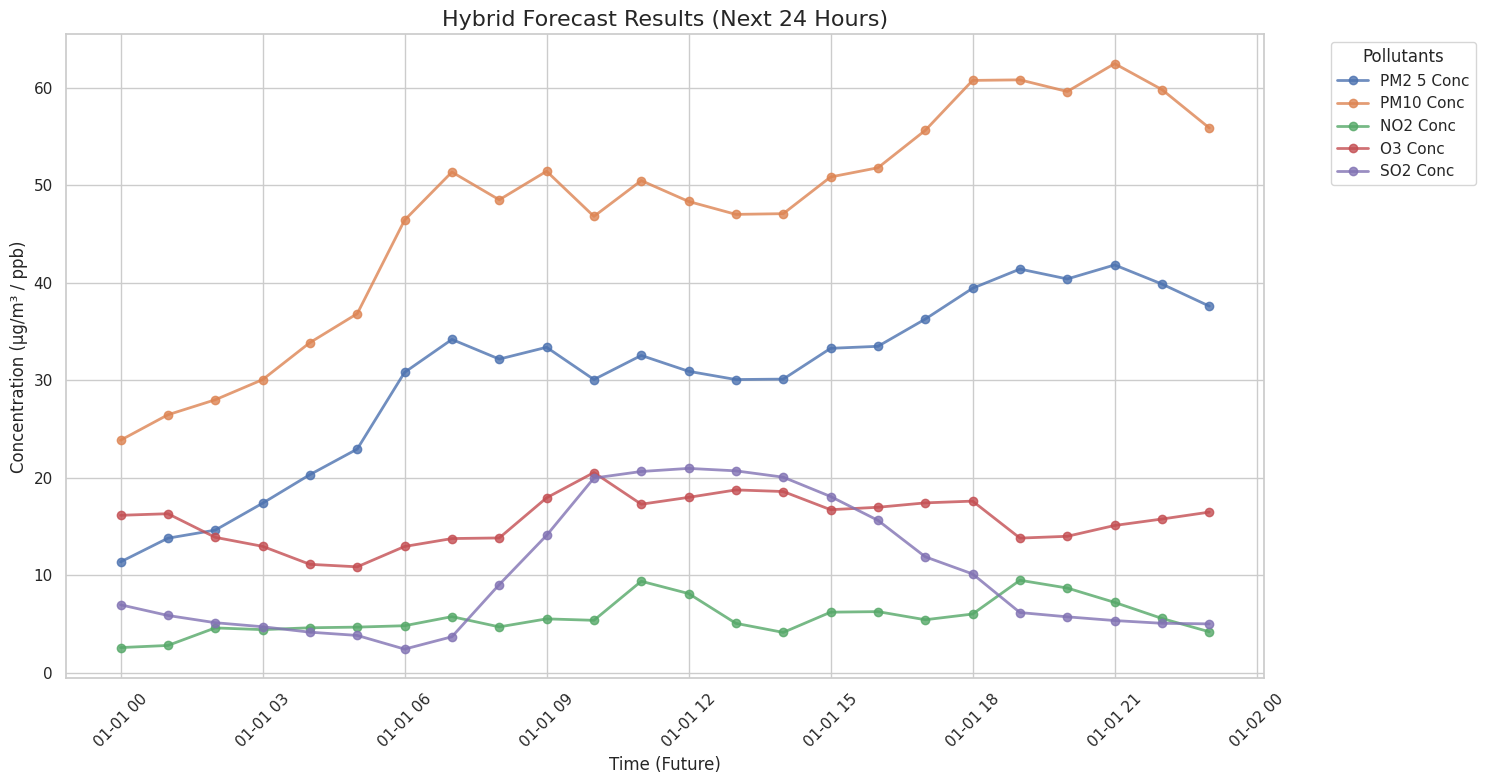

In [ ]:
# Set style for publication-quality plot
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))

# Plot all 5 pollutants
for pollutant in TARGETS:
    plt.plot(
        result_df['Time'], 
        result_df[pollutant], 
        marker='o', 
        label=pollutant,
        linewidth=2,
        alpha=0.8
    )

plt.title(f"Hybrid Forecast Results (Next {HORIZON} Hours)", fontsize=16)
plt.xlabel("Time (Future)", fontsize=12)
plt.ylabel("Concentration (µg/m³ / ppb)", fontsize=12)
plt.legend(title="Pollutants", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Save for your report
plt.savefig("hybrid_forecast_result.png", dpi=300)
plt.show()

### XAI

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Generating XAI Attention Maps...


/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


<Figure size 1500x800 with 0 Axes>

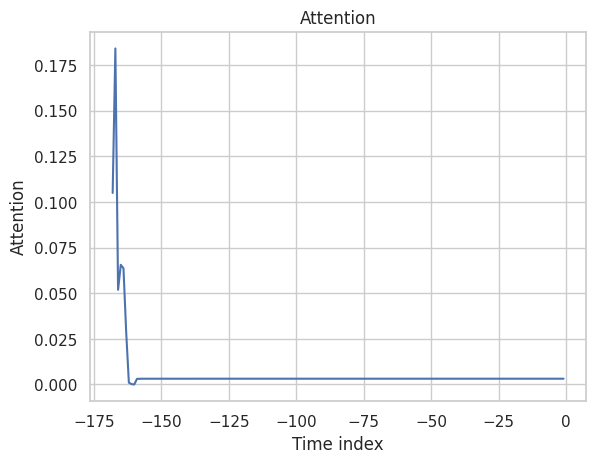

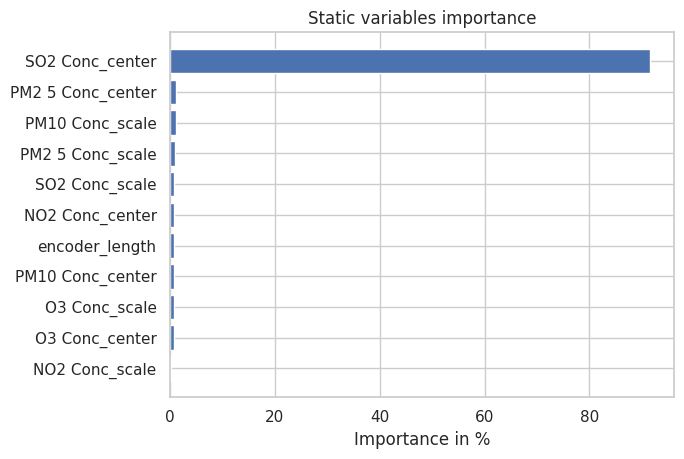

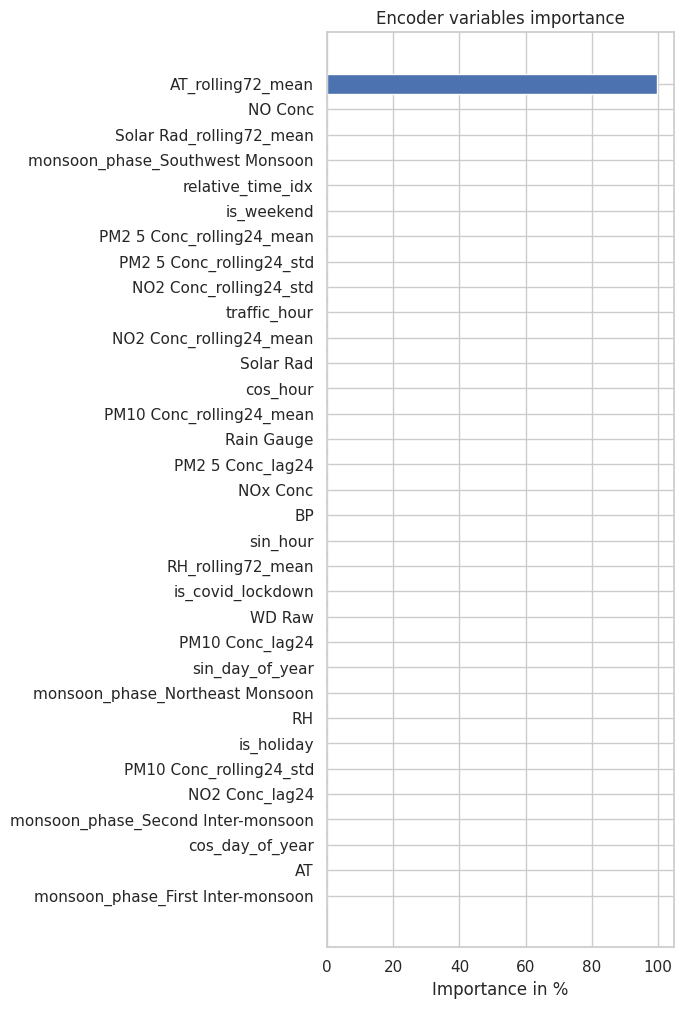

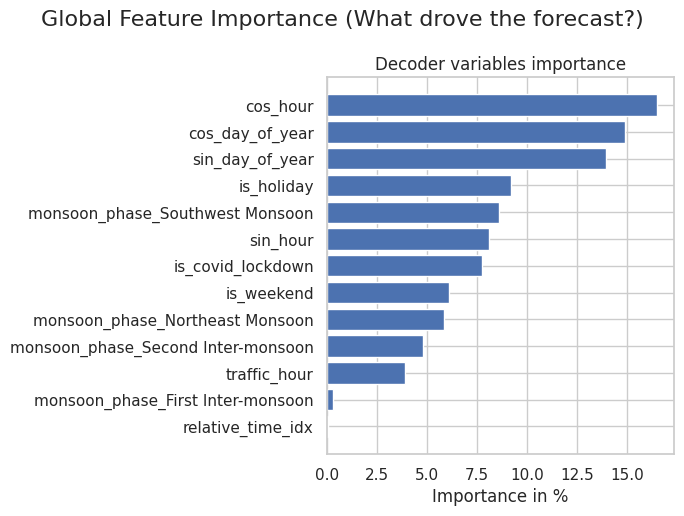

In [ ]:
print("Generating XAI Attention Maps...")

# 1. Re-run prediction with mode="raw"
# This fetches the internal 'attention' weights the model used
raw_output, x, *index = loaded_tft.predict(inference_dataloader, mode="raw", return_x=True)

# 2. Get Variable Importance from the raw output
interpretation = loaded_tft.interpret_output(raw_output, reduction="sum")

# 3. Plot the Feature Importance
# This visualizes which variables (Encoder/Decoder/Static) were most useful
plt.figure(figsize=(15, 8))
loaded_tft.plot_interpretation(interpretation)
plt.suptitle("Global Feature Importance (What drove the forecast?)", fontsize=16)
plt.tight_layout()
plt.show()

### Evaluations with Forecasting Metrics

In [ ]:
# --- 1. CONFIGURATION ---
HORIZON = 24  # Evaluation window (last 24 hours of available data)
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

# --- 2. PREPARE TEST DATA ---
# We want to predict the *last* 24 hours of the dataset
# So we must cut off the data *before* those 24 hours to simulate "past"
last_time_idx = df['time_idx'].max()
validation_cutoff = last_time_idx - HORIZON

# Ground Truth (The actual values we want to predict)
# We take the last 24 rows where time_idx > validation_cutoff
actuals_df = df[df['time_idx'] > validation_cutoff].copy()
actuals = actuals_df[TARGETS].values

print(f"Evaluating on data from time_idx {validation_cutoff+1} to {last_time_idx}")

# --- 3. TFT PREDICTION (Baseline) ---
# Create dataset for prediction (using data UP TO the cutoff)
# We need history context (encoder length) + the 24 hours we want to predict
max_encoder_length = loaded_tft.dataset_parameters['max_encoder_length']
history_cutoff = validation_cutoff - max_encoder_length

# Select rows: History + The "Future" (Validation set)
# Note: For TFT prediction mode, we provide the known future covariates (time, weather) 
# but the model predicts the targets.
evaluation_df = df[(df['time_idx'] > history_cutoff) & (df['time_idx'] <= last_time_idx)].copy()

# Reset the targets in the "future" part to 0 (to ensure no leakage, though predict=True handles this)
# evaluation_df.loc[evaluation_df['time_idx'] > validation_cutoff, TARGETS] = 0  # Optional safety

evaluation_dataset = TimeSeriesDataSet.from_parameters(
    loaded_tft.dataset_parameters,
    evaluation_df,
    predict=True,
    stop_randomization=True
)
evaluation_dataloader = evaluation_dataset.to_dataloader(train=False, batch_size=1)

print("Running TFT Evaluation Prediction...")
raw_predictions = loaded_tft.predict(evaluation_dataloader, mode="quantiles")

# Extract P50 (Median) forecast
# Shape: (1, HORIZON, Targets) -> (HORIZON, Targets)
tft_preds = torch.stack([p[..., 3] for p in raw_predictions], dim=-1).squeeze(0).detach().cpu().numpy()

# --- 4. SARIMA PREDICTION (Residual Correction) ---
print("Running SARIMA Evaluation Prediction...")
sarima_corrections = []

for target_name in TARGETS:
    if target_name in loaded_sarima_models:
        model = loaded_sarima_models[target_name]
        
        # Important: If these are pmdarima models trained on the *Training Set*,
        # .predict(n_periods=HORIZON) automatically predicts the *next* unseen steps (Test Set).
        # Assuming your training split ended exactly at 'validation_cutoff', this works perfectly.
        sarima_pred = model.predict(n_periods=HORIZON)
        sarima_corrections.append(sarima_pred)
    else:
        sarima_corrections.append(np.zeros(HORIZON))

sarima_corrections = np.column_stack(sarima_corrections)

# --- 5. HYBRID CALCULATION ---
hybrid_preds = tft_preds + sarima_corrections

# --- 6. EVALUATION METRICS ---
def calculate_metrics(y_true, y_pred, model_name="Model"):
    results = {}
    for i, target in enumerate(TARGETS):
        true_col = y_true[:, i]
        pred_col = y_pred[:, i]
        
        # Inverse log transform if your models predicted in log space
        # true_col = np.expm1(true_col)
        # pred_col = np.expm1(pred_col)

        rmse = np.sqrt(mean_squared_error(true_col, pred_col))
        mae = mean_absolute_error(true_col, pred_col)
        
        # Safe MAPE (handle zeros)
        mask = true_col != 0
        mape = np.mean(np.abs((true_col[mask] - pred_col[mask]) / true_col[mask])) * 100
        
        results[target] = {'RMSE': rmse, 'MAE': mae, 'MAPE': mape}
        
    print(f"\n--- {model_name} Performance ---")
    res_df = pd.DataFrame(results).T
    print(res_df.round(2))
    return res_df

# Compare Pure TFT vs Hybrid
print("\n========== EVALUATION RESULTS ==========")
tft_results = calculate_metrics(actuals, tft_preds, "Pure TFT Baseline")
hybrid_results = calculate_metrics(actuals, hybrid_preds, "Hybrid (TFT + SARIMA)")

# --- 7. IMPROVEMENT SUMMARY ---
print("\n========== HYBRID IMPROVEMENT ==========")
improvement = tft_results - hybrid_results
print("Positive numbers mean Hybrid reduced the error (Green is good):")
print(improvement[['RMSE', 'MAPE']].round(2))

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating on data from time_idx 38542 to 38565
Running TFT Evaluation Prediction...


/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Running SARIMA Evaluation Prediction...

========== EVALUATION RESULTS ==========

--- Pure TFT Baseline Performance ---
             RMSE    MAE    MAPE
PM2 5 Conc  12.19   9.67   44.97
PM10 Conc   14.96  11.75   30.58
NO2 Conc     5.53   4.32   38.69
O3 Conc     13.46  10.55  255.00
SO2 Conc    12.73  11.41  291.61

--- Hybrid (TFT + SARIMA) Performance ---
             RMSE   MAE    MAPE
PM2 5 Conc   9.36  6.98   31.24
PM10 Conc   11.98  8.98   23.28
NO2 Conc     6.28  5.05   42.54
O3 Conc     11.56  9.46  320.45
SO2 Conc     8.43  6.31  149.42

========== HYBRID IMPROVEMENT ==========
Positive numbers mean Hybrid reduced the error (Green is good):
            RMSE    MAPE
PM2 5 Conc  2.83   13.73
PM10 Conc   2.98    7.30
NO2 Conc   -0.75   -3.85
O3 Conc     1.91  -65.45
SO2 Conc    4.30  142.19


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Evaluating on data from time_idx 38542 to 38565
Running TFT Evaluation Prediction...


/home/dulara/project/mlgpu/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Running SARIMA Evaluation Prediction...

========== VISUALIZATION & METRICS ==========


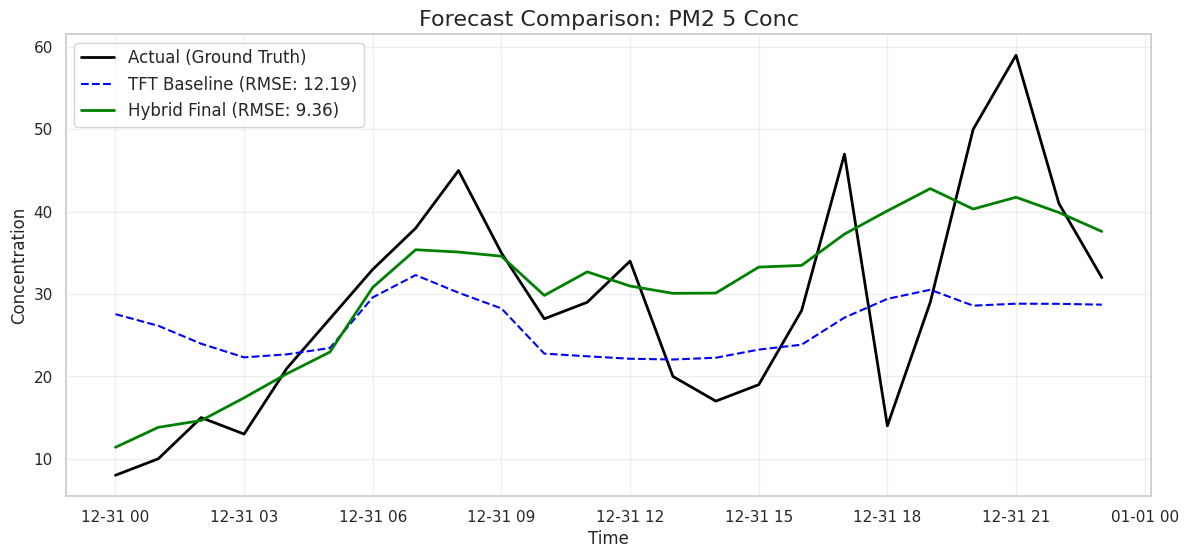

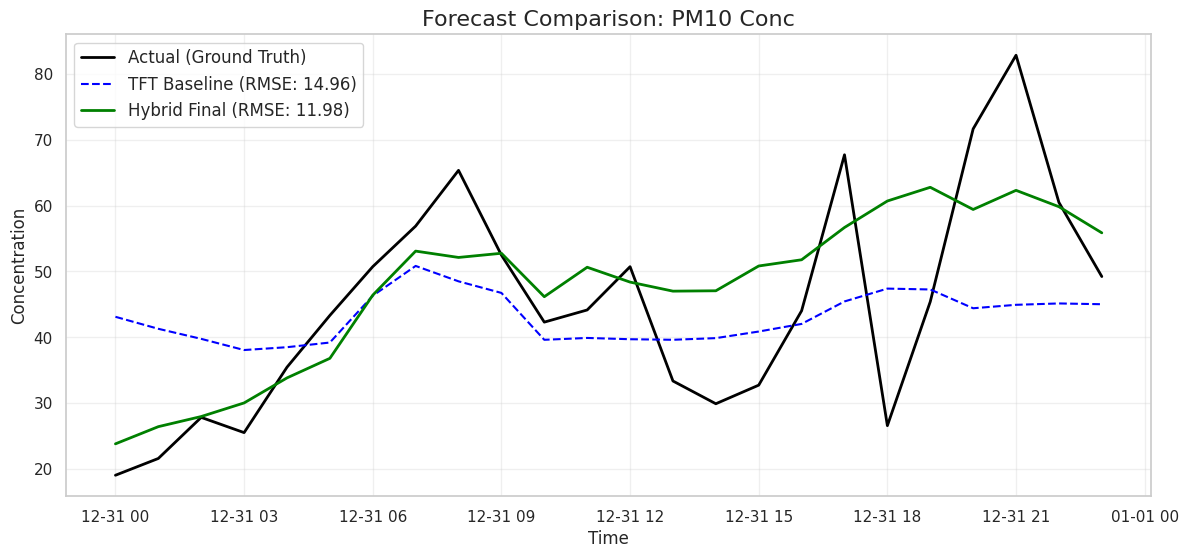

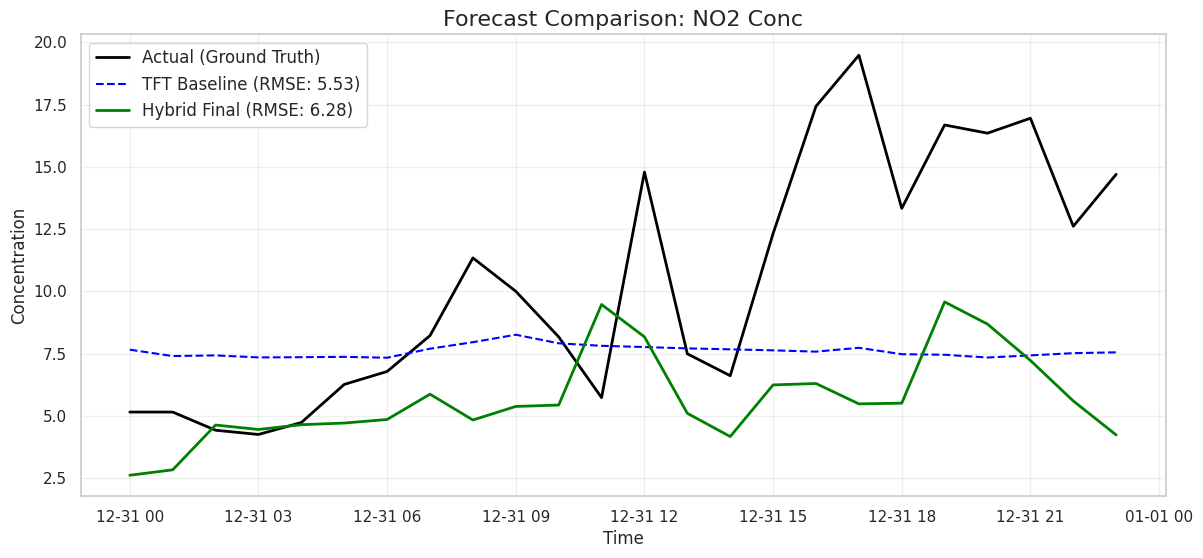

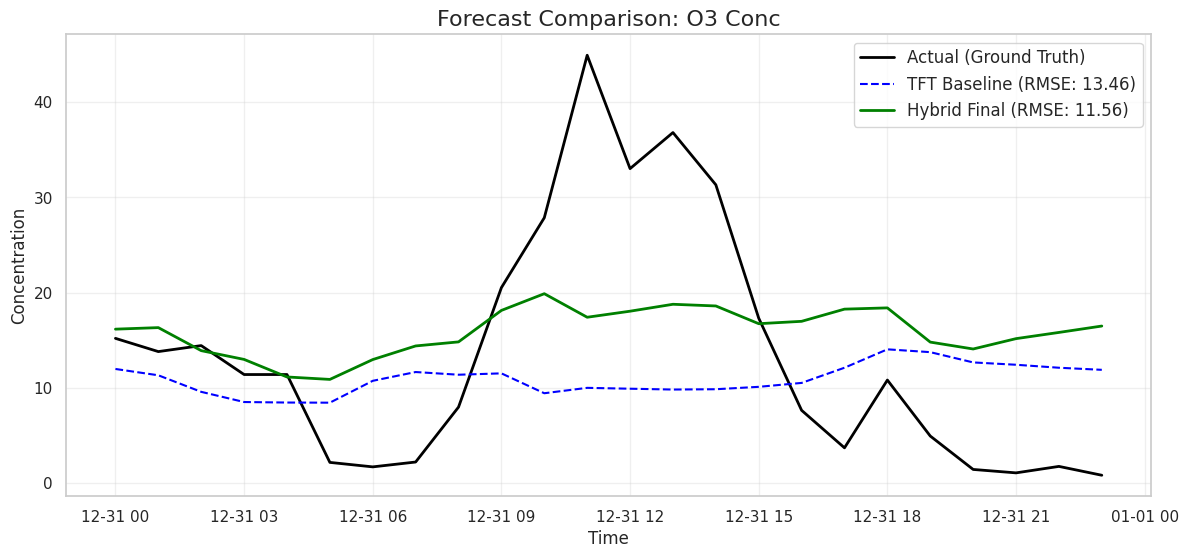

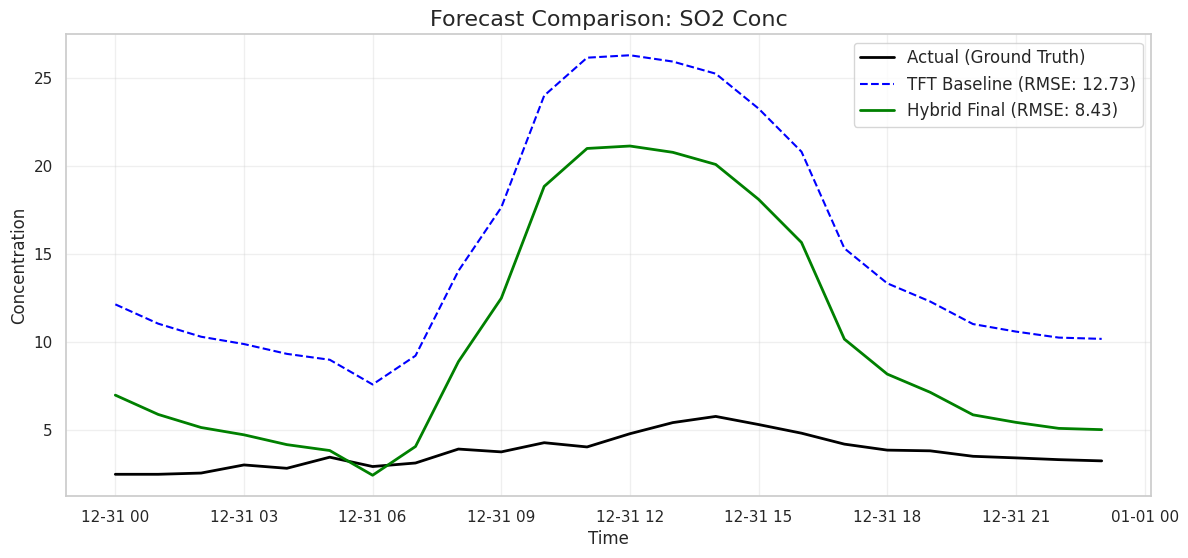


========== SUMMARY TABLE ==========
            TFT RMSE  Hybrid RMSE  TFT MAPE  Hybrid MAPE  TFT R2  Hybrid R2
PM2 5 Conc     12.19         9.36     44.97        31.24    0.13       0.49
PM10 Conc      14.96        11.98     30.58        23.28    0.16       0.46
NO2 Conc        5.53         6.28     38.69        42.54   -0.33      -0.72
O3 Conc        13.46        11.56    255.00       320.45   -0.16       0.15
SO2 Conc       12.73         8.43    291.61       149.42 -194.97     -85.00


In [ ]:
# --- 1. CONFIGURATION ---
HORIZON = 24  # Evaluation window (last 24 hours)
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

# --- 2. PREPARE TEST DATA ---
# Cut off data to simulate "The Past"
last_time_idx = df['time_idx'].max()
validation_cutoff = last_time_idx - HORIZON

# Ground Truth (The actual values we want to predict)
actuals_df = df[df['time_idx'] > validation_cutoff].copy()
actuals = actuals_df[TARGETS].values
# Get dates for plotting
plot_dates = actuals_df['Period Start Time'].values 

print(f"Evaluating on data from time_idx {validation_cutoff+1} to {last_time_idx}")

# --- 3. TFT PREDICTION (Baseline) ---
max_encoder_length = loaded_tft.dataset_parameters['max_encoder_length']
history_cutoff = validation_cutoff - max_encoder_length

evaluation_df = df[(df['time_idx'] > history_cutoff) & (df['time_idx'] <= last_time_idx)].copy()

evaluation_dataset = TimeSeriesDataSet.from_parameters(
    loaded_tft.dataset_parameters,
    evaluation_df,
    predict=True,
    stop_randomization=True
)
evaluation_dataloader = evaluation_dataset.to_dataloader(train=False, batch_size=1)

print("Running TFT Evaluation Prediction...")
raw_predictions = loaded_tft.predict(evaluation_dataloader, mode="quantiles")

# Extract P50 (Median) forecast
tft_preds = torch.stack([p[..., 3] for p in raw_predictions], dim=-1).squeeze(0).detach().cpu().numpy()

# --- 4. SARIMA PREDICTION (Residual Correction) ---
print("Running SARIMA Evaluation Prediction...")
sarima_corrections = []

for target_name in TARGETS:
    if target_name in loaded_sarima_models:
        model = loaded_sarima_models[target_name]
        sarima_pred = model.predict(n_periods=HORIZON)
        sarima_corrections.append(sarima_pred)
    else:
        sarima_corrections.append(np.zeros(HORIZON))

sarima_corrections = np.column_stack(sarima_corrections)

# --- 5. HYBRID CALCULATION ---
hybrid_preds = tft_preds + sarima_corrections

# --- 6. METRICS & PLOTTING ---
def evaluate_and_plot(y_true, y_tft, y_hybrid, dates, targets):
    results = {}
    
    # Create a figure for each target
    for i, target in enumerate(targets):
        true_col = y_true[:, i]
        tft_col = y_tft[:, i]
        hybrid_col = y_hybrid[:, i]
        
        # --- A. Metrics ---
        rmse_tft = np.sqrt(mean_squared_error(true_col, tft_col))
        rmse_hyb = np.sqrt(mean_squared_error(true_col, hybrid_col))
        
        mae_tft = mean_absolute_error(true_col, tft_col)
        mae_hyb = mean_absolute_error(true_col, hybrid_col)
        
        r2_tft = r2_score(true_col, tft_col)
        r2_hyb = r2_score(true_col, hybrid_col)
        
        # MAPE (Handling zeros)
        mask = true_col != 0
        mape_tft = np.mean(np.abs((true_col[mask] - tft_col[mask]) / true_col[mask])) * 100
        mape_hyb = np.mean(np.abs((true_col[mask] - hybrid_col[mask]) / true_col[mask])) * 100
        
        results[target] = {
            'TFT RMSE': rmse_tft, 'Hybrid RMSE': rmse_hyb,
            'TFT MAPE': mape_tft, 'Hybrid MAPE': mape_hyb,
            'TFT R2': r2_tft,     'Hybrid R2': r2_hyb
        }
        
        # --- B. Visualization ---
        plt.figure(figsize=(14, 6))
        plt.plot(dates, true_col, label='Actual (Ground Truth)', color='black', linewidth=2)
        plt.plot(dates, tft_col, label=f'TFT Baseline (RMSE: {rmse_tft:.2f})', color='blue', linestyle='--')
        plt.plot(dates, hybrid_col, label=f'Hybrid Final (RMSE: {rmse_hyb:.2f})', color='green', linewidth=2)
        
        plt.title(f"Forecast Comparison: {target}", fontsize=16)
        plt.ylabel("Concentration", fontsize=12)
        plt.xlabel("Time", fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.show()

    return pd.DataFrame(results).T

# --- 7. RUN EVALUATION ---
print("\n========== VISUALIZATION & METRICS ==========")
eval_df = evaluate_and_plot(actuals, tft_preds, hybrid_preds, plot_dates, TARGETS)

print("\n========== SUMMARY TABLE ==========")
# Reorder columns for easier reading
cols = ['TFT RMSE', 'Hybrid RMSE', 'TFT MAPE', 'Hybrid MAPE', 'TFT R2', 'Hybrid R2']
print(eval_df[cols].round(2))

In [ ]:
# Define the optimal strategy derived from your evaluation
STRATEGY = {
    'PM2 5 Conc': 'HYBRID',
    'PM10 Conc': 'HYBRID',
    'NO2 Conc':  'PURE_TFT',  # Hybrid made this worse
    'O3 Conc':   'HYBRID',
    'SO2 Conc':  'HYBRID'     # Both bad, but Hybrid was significantly better
}

print("Generating Final Optimized Forecast...")

final_forecast_selective = []

for i, target_name in enumerate(TARGETS):
    # 1. Get Base Prediction (TFT)
    tft_prediction = tft_preds[:, i]
    
    # 2. Get Correction (SARIMA)
    # Ensure sarima_corrections matches the shape of tft_preds
    if i < sarima_corrections.shape[1]:
        sarima_correction = sarima_corrections[:, i]
    else:
        sarima_correction = np.zeros_like(tft_prediction)

    # 3. Apply Strategy
    if STRATEGY.get(target_name) == 'HYBRID':
        final_value = tft_prediction + sarima_correction
        print(f"  ✅ {target_name}: Using HYBRID (TFT + SARIMA)")
    else:
        final_value = tft_prediction
        print(f"  ⚠️ {target_name}: Using PURE TFT (Skipping SARIMA)")
        
    final_forecast_selective.append(final_value)

# 4. Final Output Stack
final_forecast_array = np.column_stack(final_forecast_selective)

Generating Final Optimized Forecast...
  ✅ PM2 5 Conc: Using HYBRID (TFT + SARIMA)
  ✅ PM10 Conc: Using HYBRID (TFT + SARIMA)
  ⚠️ NO2 Conc: Using PURE TFT (Skipping SARIMA)
  ✅ O3 Conc: Using HYBRID (TFT + SARIMA)
  ✅ SO2 Conc: Using HYBRID (TFT + SARIMA)



========== FINAL OPTIMIZED MODEL REPORT ==========


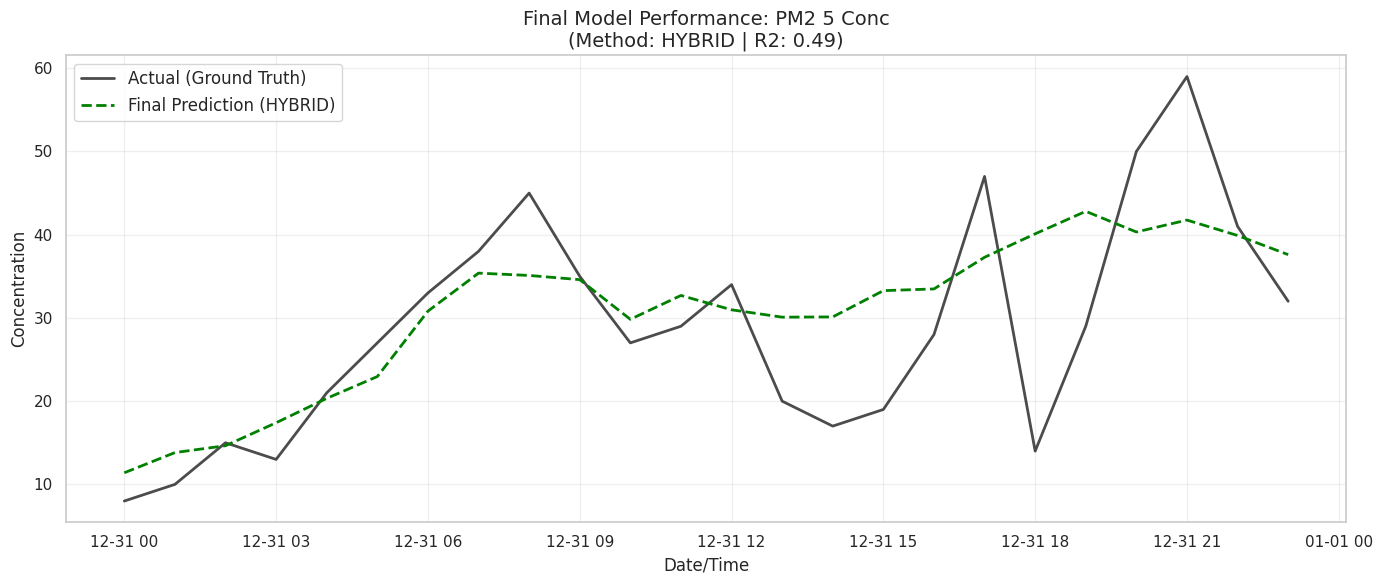

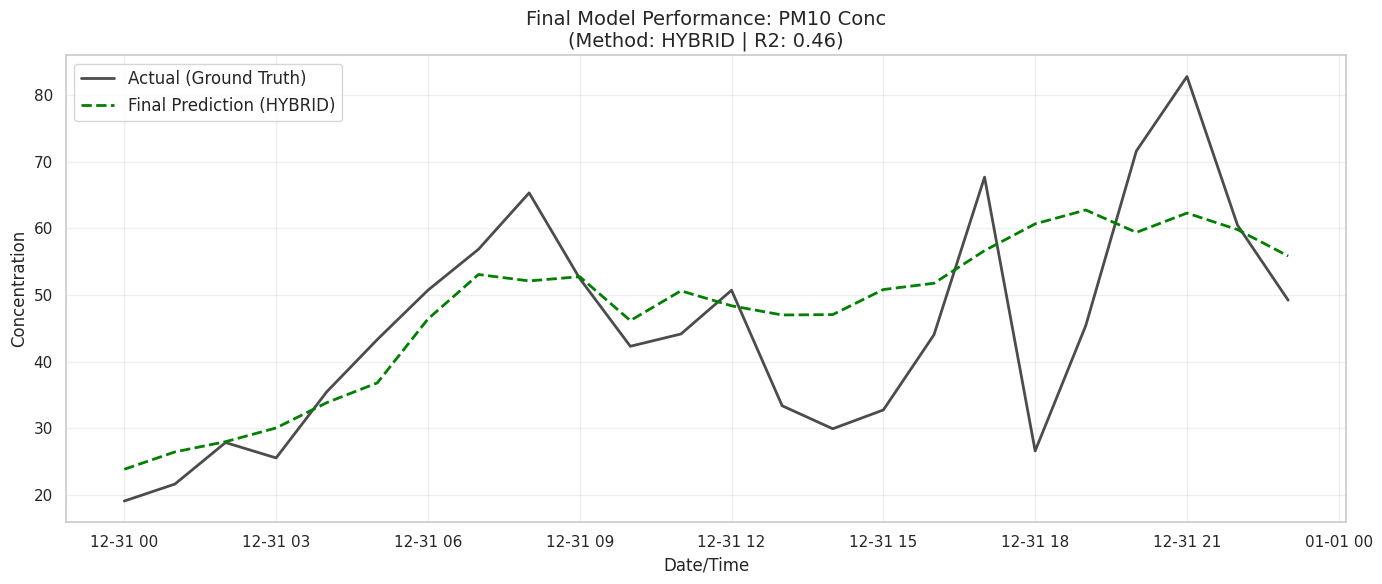

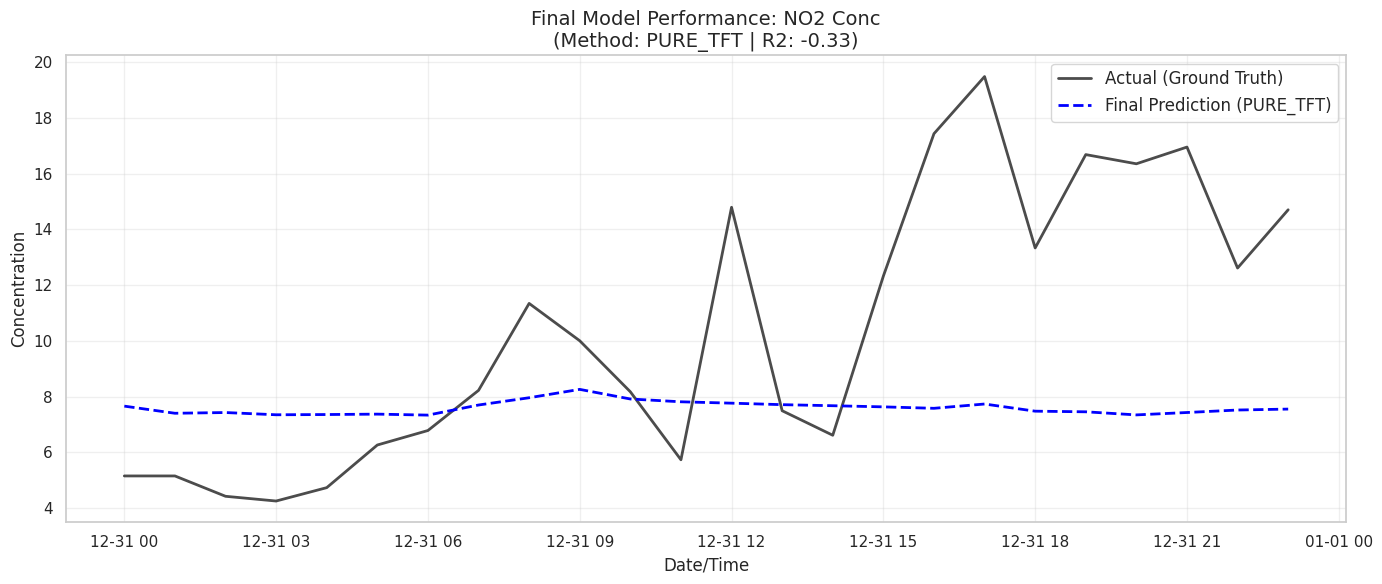

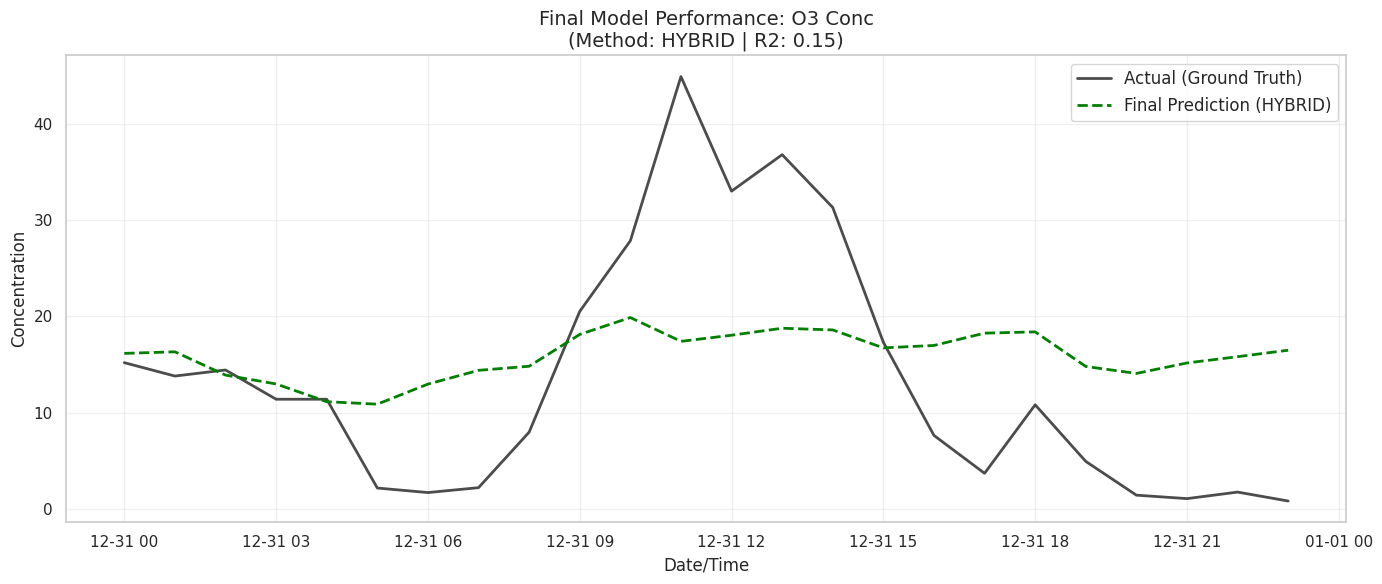

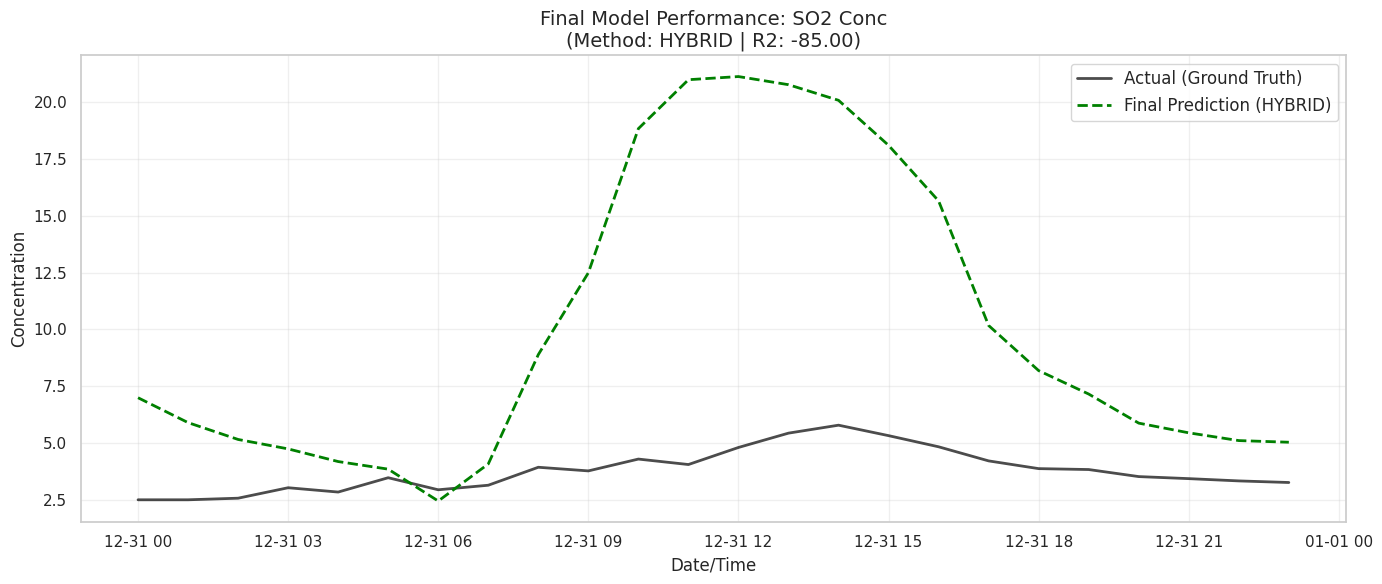



 Pollutant Chosen Model   RMSE   MAE  MAPE (%)  R2 Score
PM2 5 Conc       HYBRID  9.356 6.982    31.237     0.489
 PM10 Conc       HYBRID 11.978 8.984    23.282     0.464
  NO2 Conc     PURE_TFT  5.529 4.316    38.690    -0.331
   O3 Conc       HYBRID 11.556 9.457   320.453     0.145
  SO2 Conc       HYBRID  8.434 6.308   149.419   -85.002


In [ ]:
# --- 1. DEFINE EVALUATION FUNCTION ---
def evaluate_final_model(y_true, y_pred, dates, targets, strategy_dict):
    metrics_list = []
    
    # Loop through each pollutant
    for i, target in enumerate(targets):
        true_col = y_true[:, i]
        pred_col = y_pred[:, i]
        
        # A. Calculate Metrics
        rmse = np.sqrt(mean_squared_error(true_col, pred_col))
        mae = mean_absolute_error(true_col, pred_col)
        r2 = r2_score(true_col, pred_col)
        
        # MAPE (Handle zeros safely)
        mask = true_col != 0
        mape = np.mean(np.abs((true_col[mask] - pred_col[mask]) / true_col[mask])) * 100
        
        # Store for table
        chosen_method = strategy_dict.get(target, "Unknown")
        metrics_list.append({
            "Pollutant": target,
            "Chosen Model": chosen_method,
            "RMSE": rmse,
            "MAE": mae,
            "MAPE (%)": mape,
            "R2 Score": r2
        })
        
        # B. Plotting
        plt.figure(figsize=(14, 6))
        
        # Plot Actuals
        plt.plot(dates, true_col, label='Actual (Ground Truth)', color='black', linewidth=2, alpha=0.7)
        
        # Plot Prediction
        # We color-code based on the model type used
        line_color = 'green' if chosen_method == 'HYBRID' else 'blue'
        plt.plot(dates, pred_col, label=f'Final Prediction ({chosen_method})', color=line_color, linewidth=2, linestyle='--')
        
        # Styling
        plt.title(f"Final Model Performance: {target}\n(Method: {chosen_method} | R2: {r2:.2f})", fontsize=14)
        plt.ylabel("Concentration", fontsize=12)
        plt.xlabel("Date/Time", fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return pd.DataFrame(metrics_list)

# --- 2. RUN EVALUATION ---
print("\n========== FINAL OPTIMIZED MODEL REPORT ==========")


final_report = evaluate_final_model(
    actuals,                
    final_forecast_array,   
    plot_dates,             
    TARGETS,                
    STRATEGY
)

# --- 3. PRINT SUMMARY TABLE ---
print("\n")
print(final_report.round(3).to_string(index=False))